# Machine Learning — Assignment 3 — Linear Model Tuning (Regression)

University of Granada (UGR), 2022–23  
Author: **Juan Pablo Escudero Ramírez**

Ridge, Lasso, and hyperparameter search with scikit-learn on the Online News Popularity dataset.

---


<font color='blue'>This work focuses on fitting and selecting the best linear predictor for a given data set. To do this, it is recommended to use the Scikit-Learn library (https://scikit-learn.org/). This library contains high-level functions that can be very useful for the development of the practice. In any case, for each Scikit-Learn function that is used, you must explain why its use is necessary, as well as explain its operation and the meaning of all its parameters. Related to this point, the default values ​​in the library are not considered justified choices $\textit{a priori}$ and, as in the rest of practice, decisions without justification and results without interpretation will not be considered valid.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1)


In [2]:
# Environment: works locally (GitHub/Jupyter) and on Google Colab
import sys
from pathlib import Path

from paths import ROOT, get_data
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


#### <font color='blue'>1) Analyze and adequately describe the problem to be solved. Identify the $X$, $Y$ and $f$ elements of the problem, and describe them in detail. 0.5 points.


The problem to be solved is the prediction of the number of times an article is shared online based on the characteristics or attributes associated with said article. The aim is to build a predictive model that estimates the popularity of the article before publishing it.

\\

The dataset used is "Online News Popularity" which contains information about the articles published by Mashable in a period of 2 years, with a total of 39,645 instances and 61 attributes that were obtained from Prado, of which the first 2 are "non-predictive" and the last attribute is the target "shares" that represents the number of times an article is shared.

\\

Taking this into account that there are 58 attributes that are not "non-predictive" and that the other attribute that remains is the one that should be predicted. The set $X$ should be the set of these 58 attributes. Something to note is that of these 58 attributes, 14 are categorical even though they are expressed in a binary way.

\\

The $Y$ element is the set of values that contains the "share" attribute since it is our target, our attribute to predict.

\\

To define $f$ we have to take into account that the main objective is to use the "predictive" attributes to predict the target attribute "shares". Therefore, the objective function is defined as $f:X→Y$, where $X$ is the set of features of an article and $Y$ represents the number of times an article was shared.

\\

The objective of solving this problem is the development of a model capable of learning from the input characteristics and predicting the "share" characteristic.


In [3]:
# Data reading
dataset = pd.read_csv(get_data('OnlineNewsPopularity.csv'), header=0)


In [4]:
print("Dataset dimensions:",dataset.shape)


Dimensiones del dataset:  (39644, 61)


In [5]:
# Delete the first two non-predictive columns and the last "shares"
X = dataset.iloc[:, 2:-1]

# Get the column that is target
Y = dataset.iloc[:,-1]

print("X Dimensions:",X.shape)
print("Y Dimensions:",Y.shape)


Dimensiones de X:  (39644, 58)
Dimensiones de Y:  (39644,)


In [6]:
pd.set_option('display.max_columns', None)
print(dataset.head())


                                                 url   timedelta  \
0  http://mashable.com/2013/01/07/amazon-instant-...       731.0   
1  http://mashable.com/2013/01/07/ap-samsung-spon...       731.0   
2  http://mashable.com/2013/01/07/apple-40-billio...       731.0   
3  http://mashable.com/2013/01/07/astronaut-notre...       731.0   
4   http://mashable.com/2013/01/07/att-u-verse-apps/       731.0   

    n_tokens_title   n_tokens_content   n_unique_tokens   n_non_stop_words  \
0             12.0              219.0          0.663594                1.0   
1              9.0              255.0          0.604743                1.0   
2              9.0              211.0          0.575130                1.0   
3              9.0              531.0          0.503788                1.0   
4             13.0             1072.0          0.415646                1.0   

    n_non_stop_unique_tokens   num_hrefs   num_self_hrefs   num_imgs  \
0                   0.815385         4.0          

Taking into account that within the data there are 14 binary categorical characteristics when reviewing the dataset, a correlation matrix would not be useful at this moment, but later in its separation it would be. By visualizing the variables I obtain knowledge of the existence of the categorical data, which without knowing them I would have resolved everything as if they were continuous data.


#### <font color='blue'>2) Identify which sets of hypotheses will be used and justify said choice. 0.25 points.


3 hypotheses will be used using linear models:

* Linear Regression: This model is very basic but can provide interpretable results, since the existence of a linear relationship between the input characteristics and the target can be detected. With good data manipulation these relationships can be interpreted. In addition, it has great computational efficiency, coming in handy for a problem with such a large number of instances. Taking into account that there are continuous characteristics and the categorical ones are binary [0, 1], it is not a problem to use it to know the linearity and if it is possible for this data. The set of hypotheses is composed of all possible linear functions that relate the input characteristics to the output variable. Each hypothesis is represented by a linear combination of the attributes, where the coefficients correspond to the weights assigned to each characteristic.

\\
* Ridge: This model implements an L1 recularization, which helps control overfitting by improving the generalization of the model, making it beneficial for data from so many instances. As I have read, this model works well with characteristics of both types, therefore it is an adequate treatment due to the possibility of finding correlations between categorical characteristics. The set of hypotheses is similar to that of linear regression, but with the addition of L2 regularization. This means that the assumptions in the Ridge regression are penalized based on the magnitude of the coefficients. L2 regularization helps control overfitting by adding a penalty term to the objective function, leading to smaller coefficients and a simplification of the model.

\\
* Lasso: This model, internally, tries to reduce multicollinearity in the data set by reducing correlated attributes, so if after all the data manipulation that is done there are still some, the model can reduce them, leaving us with the most important characteristics. The hypothesis set also consists of all possible linear functions that relate the input characteristics to the output variable. However, in this case L1 regularization is used, which implies that the hypotheses are penalized based on the sum of the absolute values ​​of the coefficients. L1 regularization has the property of performing feature selection by making some coefficients exactly zero, leading to a sparser and more interpretable model.

\\

Linear regression is a basic option but provides interpretable results. Lasso and Ridge offer advantages such as overfitting control and feature selection.

The hypothesis sets for linear regression, ridge, and lasso are based on linear functions, but differ in the way regularization is incorporated and how it affects the model coefficients.


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso


#### <font color='blue'>3) If the database defines training and test sets, join them into a single set and generate your own sets. Describe and justify the partition mechanism. 0.75 points.


The data was already in a single set, as shown in exercise 1 with $X$ and $Y$. So we proceed to separate the data into training and test sets.

The 'train_test_split' function from the sklearn library was used. The sets $X$ and $Y$ are passed to this as parameters since they are the data to be separated.

Another parameter is 'test_size' which was assigned 0.2, indicating that 20% of the data will be allocated to the test set, while the remaining 80% will be used for the training set. This value was chosen taking into account the size of the data, 0.1 was a good value but we wanted to have a greater margin for testing rather than learning.

The last parameter is the 'random_state' which was assigned 0 to ensure reproducibility of the partition. This means that every time the code is executed, the same data partition will be obtained.

Therefore, by applying this, the data was partitioned into training and test sets, using the train_test_split function with a test size of 20% and a random seed of 0.


In [8]:
from sklearn.model_selection import train_test_split


In [9]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2,random_state=0)


#### <font color='blue'>4) Justify all the details of data preprocessing (coding, transformation, normalization, etc.). That is, all the manipulations on the initial data that allow us to set the set of feature vectors that will be used in training. 1 point.  

<font color='blue'>Note: Non-linear transformations of variables can be defined from the powers and
products of powers of the original variables, sets of orthogonal polynomials, etc. If
use non-polynomial transformations of the variables such as $log$, $\sqrt{()}$, $sin$, etc., you must justify the
their interest.


##### Division of data between categorical and continuous.


This division was made with the intention of subsequently manipulating the data, applying different transformations in search of a better result.


In [10]:
# categorical characteristics
Index = [' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world']


In [11]:
# continuous features
columns_to_keep = x_train.columns.isin(Index)


* x_train_co and x_test_co represent the continuous characteristics of the instances, while x_train_ca and x_test_ca represent the categorical characteristics.


In [12]:
x_train_ca = x_train.loc[:, columns_to_keep]
x_train_co = x_train.drop(columns = Index)

x_test_ca = x_test.loc[:, columns_to_keep]
x_test_co = x_test.drop(columns = Index)


In [13]:
print("Dimension of x_train categorical features:",x_train_ca.shape)
print("Dimension of x_train continuous features:",x_train_co.shape)

print("Dimension of x_train categorical features:",x_test_ca.shape)
print("Dimension of x_train continuous features:",x_test_co.shape)


Dimensión de las características categóricos de x_train: (31715, 14)
Dimensión de las características continuas de x_train: (31715, 44)
Dimensión de las características categóricos de x_train: (7929, 14)
Dimensión de las características continuas de x_train: (7929, 44)


##### Processing of continuous data:


To begin the treatment of continuous data, the Pearson correlation matrix is ​​shown and is used to evaluate the linear relationship between pairs of continuous variables. This matrix is ​​a table that shows the Pearson correlation coefficients between all possible combinations of variables in a data set.

The Pearson correlation coefficient is a number that varies between -1 and 1, where:

* A value of 1 indicates a perfect positive correlation, meaning the variables are linearly related and increase together.
* A value of -1 indicates a perfect negative correlation, meaning that the variables are linearly related but one decreases while the other increases.
* A value close to 0 indicates a weak or no correlation, meaning there is no apparent linear relationship between the variables.

\\

It allows identifying highly correlated variables, which may indicate a linear dependence between them. This can be useful in feature selection tasks.


###### Correlation matrix:


In [14]:
import seaborn as sns

# Function that displays the correlation matrix
def MCorrPear(CorrM):
  # Creating a figure and axis
  fig, ax = plt.subplots(figsize=(14, 12))

  # Generating the visualization of the correlation matrix with colors
  sns.heatmap(CorrM,  cmap='coolwarm', linewidths=0.5, ax=ax)

  # Setting Axis Titles
  ax.set_title('Pearson correlation matrix')

  # Show the figure
  plt.show()


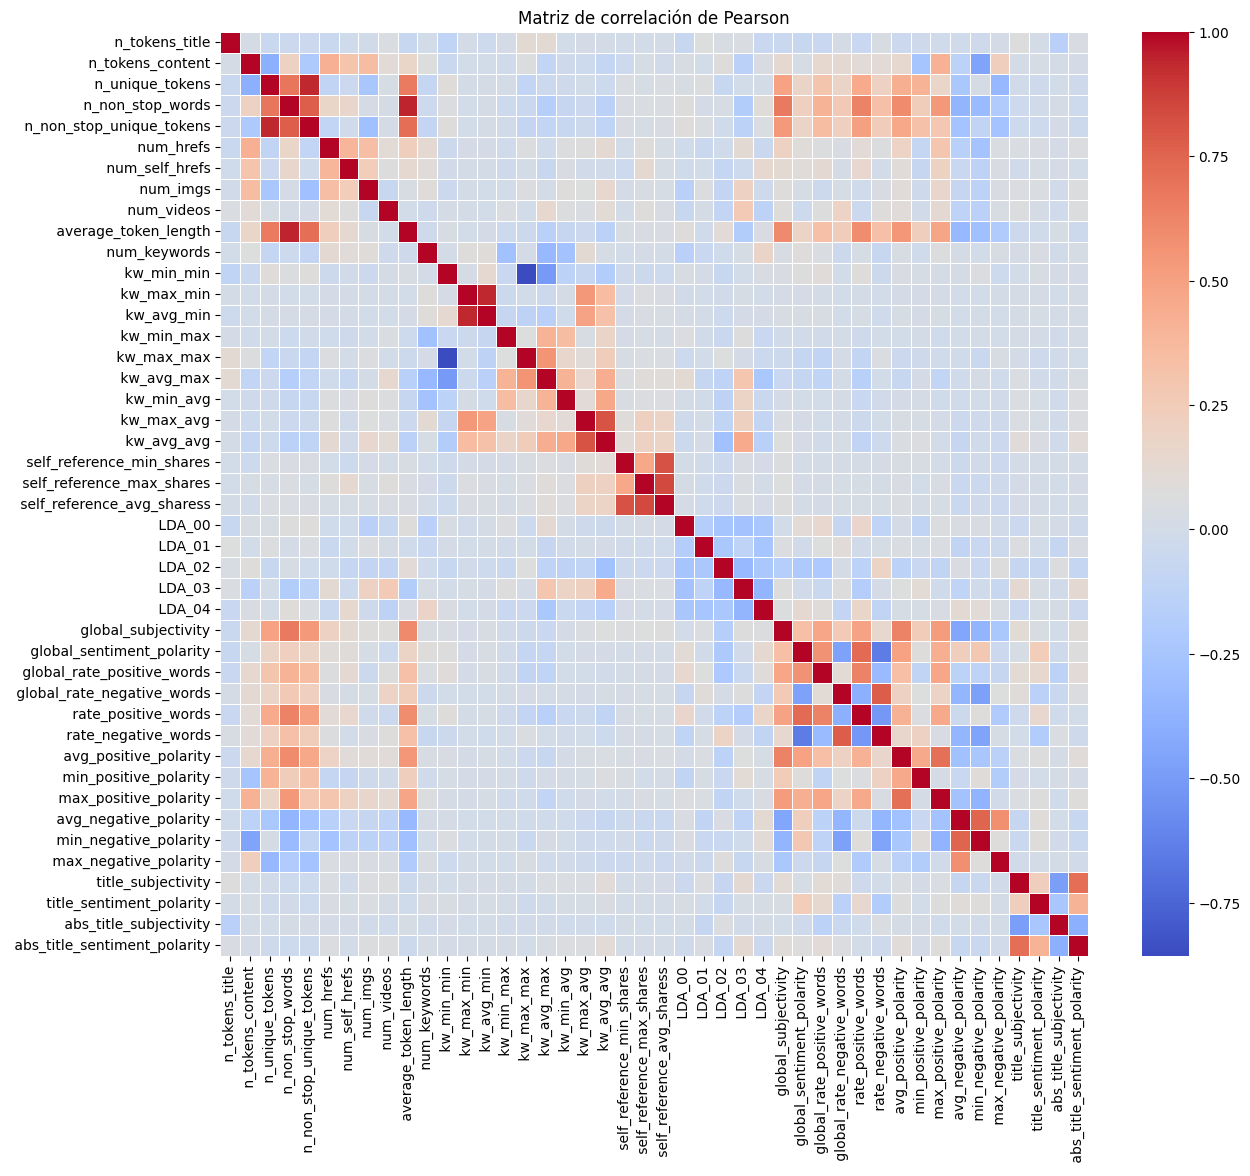

In [15]:
CorrelacionPearson = x_train_co.corr(method='pearson')
MCorrPear(CorrelacionPearson)


As you can see, there are some variables highly correlated, positively or negatively, specifically I have observed a high correlation between the following variables:

* n_non_stop_unique_tokens - n_unique_tokens
* average_token_length - n_non_stop_words
* kw_max_max - k_min_min
* kw_avg_min - kw_max_min

Therefore I decide to select one of the two, thus reducing the size of the data and the possibility of overfitting.


In [16]:
# Columnas a eliminar
Delete_col = [' n_non_stop_unique_tokens',' average_token_length' ,' kw_max_max', ' kw_avg_min']

# Column removal
x_train_co = x_train_co.drop(columns = Delete_col)
x_test_co =  x_test_co.drop(columns = Delete_col)


###### Eliminar Outilers


It is important to take into account extraordinary values ​​as they could bias the results of the models. I have chosen not to destroy data but to use the IQR method which is based on the following:
* Calculate the interquartile range (IQR) as the difference between the third quartile (Q3) and the first quartile (Q1)
*Calculate the lower and upper limits as Q1 - 1.5 * IQR and Q3 + 1.5 * IQR, respectively.
* All values ​​that are less than the lower limit or greater than the upper limit are considered outliers.
* Modify the outliers to give them the values ​​of 'upper_limit' and 'lower_limit'.

During the experimentation, the quartiles gave me problems since when using 0.25 and 0.75 as the first and third quartiles, the values ​​of the 'kw_max_max' column had the same value at all times, so I have chosen to expand the range to 0.2 and 0.8, solving the problem.


In [17]:
def removeOutliers(x_train, x_test):

  x_train_c, x_test_c = x_train.copy(), x_test.copy()
  outilers = []

  n_cols = x_train.columns

  for column in n_cols:
    q1 = x_train[column].quantile(0.2)
    q3 = x_train[column].quantile(0.8)
    IQR = q3 - q1

    lower_limit = q1 - 1.5 * IQR
    upper_limit = q3 + 1.5 * IQR
      
    outlier_serie = x_train[ (x_train[column] < lower_limit ) | (x_train[column] > upper_limit) ]
    outliers = np.append(outilers, (len(outlier_serie)))

    x_train_c[column][x_train_c[column] <= lower_limit] = lower_limit
    x_train_c[column][x_train_c[column] >= upper_limit] = upper_limit

    x_test_c[column][x_test_c[column] <= lower_limit] = lower_limit
    x_test_c[column][x_test_c[column] >= upper_limit] = upper_limit

  return x_train_c, x_test_c


In [18]:
x_train_co, x_test_co = removeOutliers(x_train_co, x_test_co)


###### Data normalization


It is important to normalize the data as features can have different scales and values, so we ensure that all features are on a comparable scale. In addition, it is subsequently planned to use PCA taking advantage of the fact that the data is continuous and if the units of measurement of the characteristics are different, this may affect the PCA analysis. We normalize allow PCA to be based solely on the correlation structure between features. And, although we have addressed outliers, normalizing reduces the influence of outliers on the analysis.


In [19]:
from sklearn import preprocessing

def preprocessing_data(x_train, x_test):
    # Normalizar x_train
    scaler = preprocessing.StandardScaler()
    x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns, index=x_train.index)
    
    # Apply the same transformation to x_test
    x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns, index=x_test.index)
    
    return x_train_scaled, x_test_scaled


In [20]:
x_train_co, x_test_co = preprocessing_data(x_train_co, x_test_co)


###### PCA application


When applying PCA we must be careful and make sure that the data is continuous. One of the reasons we separate the data.

\\

When applying PCA we seek to retain n_components that represent a percentage of the total variance. So applying it to our data brings many benefits:

* Dimensionality reduction: PCA allows you to reduce the dimensionality of the data by projecting it into a new lower-dimensional space that preserves most of the variance of the original data

* Identification of hidden patterns and structures: By applying PCA, the principal components are obtained, which are linear combinations of the original characteristics. These principal components represent directions in the feature space where the data has the greatest variance.

* Elimination of multicollinearity: Principal components are chosen so that they are orthogonal to each other, which helps reduce or eliminate multicollinearity in the data.

* Performance improvement: By reducing the dimensionality of data with PCA, an improvement in the performance of machine learning models can be achieved. It also helps to reduce the probability of overfitting in the models.


The following graph shows the n_components that should be taken to have a covariance of 96%.


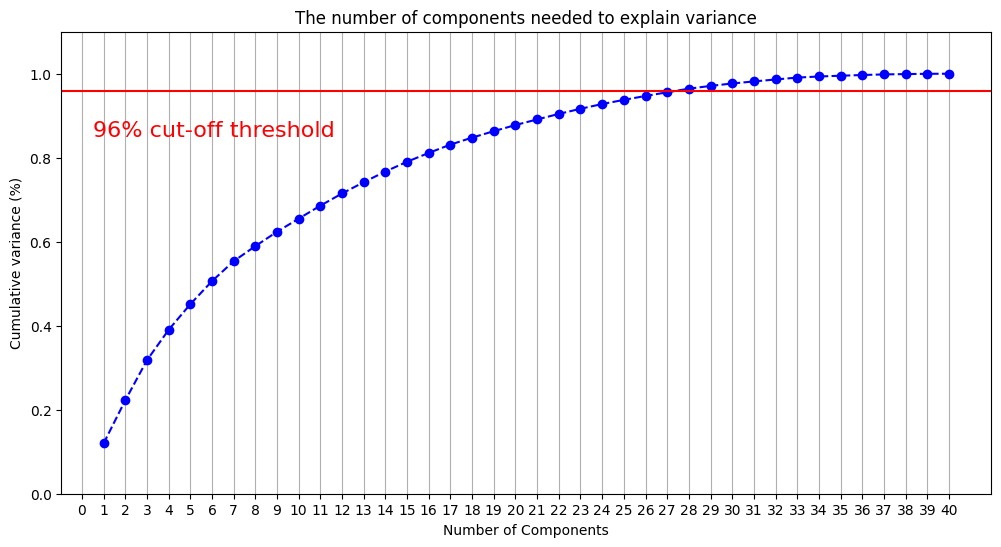

In [21]:
from sklearn.decomposition import PCA

pca = PCA().fit(x_train_co)

plt.rcParams["figure.figsize"] = (12, 6)

fig, ax = plt.subplots()
n_components = x_train_co.shape[1]
xi = np.arange(1, n_components + 1, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0, 1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, n_components + 1, step=1))
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.96, color='r', linestyle='-')
plt.text(0.5, 0.85, '96% cut-off threshold', color='red', fontsize=16)

ax.grid(axis='x')
plt.show()


When applying PCA, we choose the n_components that allow us to retain 96% of the total variance.


In [22]:
def pca(x_train, x_test, value):
    print("\nDimensionality before PCA:", x_train.shape[1])

    pca = PCA(n_components=value)
    pca.fit(x_train)

    x_train_pca = pca.transform(x_train)
    x_test_pca = pca.transform(x_test)

    # Get new column names after PCA
    column_names = [f"PCA_{i+1}" for i in range(x_train_pca.shape[1])]

    # Create new Pandas DataFrames with the transformed data and column names
    x_train_pca = pd.DataFrame(x_train_pca, columns=column_names)
    x_test_pca = pd.DataFrame(x_test_pca, columns=column_names)

    print("\nDimensionality after PCA:", x_train_pca.shape[1])

    return x_train_pca, x_test_pca


It was chosen to retain 96% of the total variance to stay in the 95%-99% range but choose fewer components, thus lowering the dimensionality.


In [23]:
x_train_co, x_test_co = pca(x_train_co, x_test_co, 29)



Dimensionality before PCA: 40

Dimensionality after PCA: 29


##### Categorical:


The categorical characteristics are binary, but in themselves they are very few, being only 14 compared to the continuous characteristics. The following graph shows the Pearson correlation coefficients between binary characteristics and the target variable $Y$.


<Axes: >

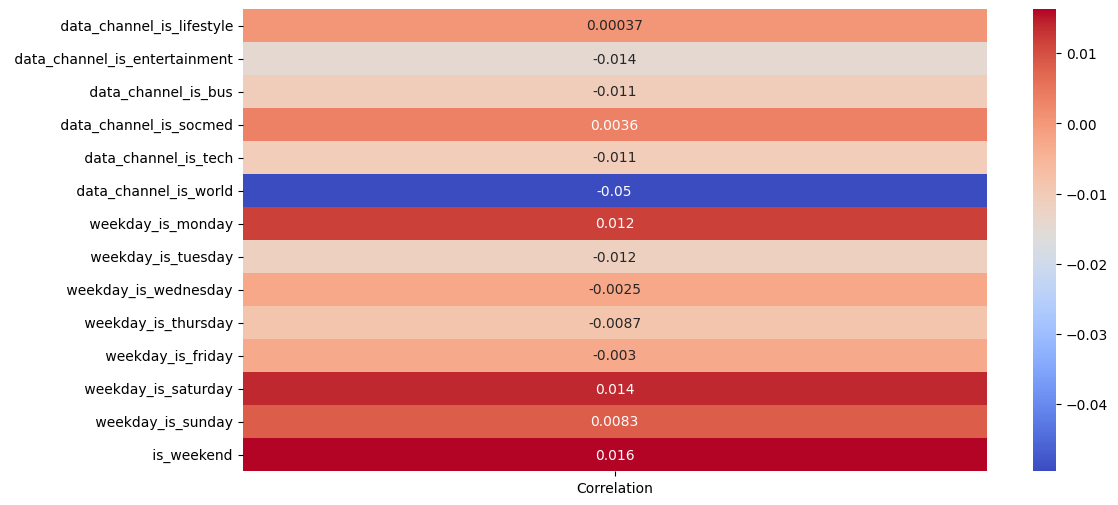

In [24]:
from scipy.stats import pointbiserialr
import seaborn as sns

# Calculates the Pearson correlation coefficient between binary features and the target variable
correlations = {}
for feature in x_train_ca:
    corr, _ = pointbiserialr(x_train_ca[feature], y_train)
    correlations[feature] = corr

# Create a dataframe with the correlation coefficients
df_correlations = pd.DataFrame(correlations, index=['Correlation']).T

# Visualize the correlation matrix using seaborn
sns.heatmap(df_correlations, annot=True, cmap='coolwarm')

#print(df_correlations)


The only treatment that was going to be done to the categorical data was to eliminate redundant columns.


In [25]:
def check_redundant_columns(df):
    redundant_columns = df.columns[df.nunique() == 1]
    
    if redundant_columns.empty:
        print("No se encontraron columnas redundantes.")
    else:
        print("Se encontraron columnas redundantes:")
        print(redundant_columns)


In [26]:
check_redundant_columns(x_train_ca)
check_redundant_columns(x_test_ca)


No se encontraron columnas redundantes.
No se encontraron columnas redundantes.


##### Join continuous and categorical data


After processing the data, they are joined again, thus obtaining x_train and x_test.


In [27]:
x_train_ca = x_train_ca.reset_index(drop=True)
x_train_co = x_train_co.reset_index(drop=True)

x_train = pd.concat([x_train_co, x_train_ca], axis=1)

x_test_ca = x_test_ca.reset_index(drop=True)
x_test_co = x_test_co.reset_index(drop=True)

x_test = pd.concat([x_test_co, x_test_ca], axis=1)


#### <font color='blue'>5) Justify the error metrics and loss function to use. Discuss its suitability for the problem. 0.5 points.


The error metric to be used is $R^2$. It provides a measure of how much variance of the dependent variable is explained by the model.

The value of $R^2$ varies between 0 and 1. 
* A value of $R^2$ equal to 1 indicates that the model is able to explain all the variability of the dependent variable, that is, all data points fall exactly on the regression line. 
* A value of $R^2$ equal to 0 indicates that the model cannot explain the variability of the dependent variable and fits worse than a horizontal line.

\\

It is calculated in the following way: 

$R^2$ = 1 - (SSR/SST)

* SSR (Sum of Squares Residual) is the sum of the squared residuals, which represents the difference between the values predicted by the model and the actual values observed.

* SST (Sum of Squares Total) is the total sum of the squares, which represents the difference between the actual observed values ​​and the mean of the dependent variable.


This function is used because it is considered that it gives more interpretable results as it is bounded between 0 and 1.


In [28]:
def r2_score(y_true, y_pred):
    numerator = np.sum((y_true - y_pred)**2)
    denominator = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (numerator / denominator)


Since models from the 'sklean' library are going to be used, each one already has its loss function implemented.

* Linear Regression: Uses the ordinary least squares loss function, minimizing the sum of the squares of the differences between the predicted values ​​​​and the actual values. The objective is to minimize the mean squared error (MSE).

* Ridge Regression: Uses least squares loss function with L2 regularization. In addition to the mean square error term, a regularization term is added that penalizes the regression coefficients. The minimized loss function is the sum of the squares of the differences between the predicted values ​​and the actual values, together with the product of the regularization parameter (alpha) and the L2 norm of the coefficients. The L2 norm penalizes large coefficients and helps avoid overfitting.

* Lasso Regression: Lasso regression uses least squares loss function with L1 regularization. As in Ridge, a regularization term is added to the loss function to penalize the coefficients. However, instead of the L2 norm, the L1 norm of the coefficients in the regularization term is used. The L1 norm has the property of making some coefficients exactly zero, which leads to automatic feature selection and sparse modeling approach.


#### <font color='blue'>6) Discuss all the parameters and the type of regularization used in fitting the selected models. Justify the suitability of the chosen regularization. 1 point.


Scikit-learn's GridSearchCV function is used to fit each model using a 5-fold cross-validated grid search (cv=5). The R2 metric (scoring=r2_scorer) is used as a performance measure to evaluate and compare the models. 

When using GridSearchCV, all possible combinations of parameters will be tested to find the best configuration that optimizes the selected evaluation metric, in this case the R2 coefficient.


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer


In [30]:
def draw_best_model(model):
    print("Best parameters: ", model.best_params_)
    print("Best cross-validation result: ", model.best_score_)


The parameters used in linear regression are:

* fit_intercept: This indicates whether or not to fit the model bias. It has two values, whether it fits or not.
* copy_X: Indicates whether a copy of the feature matrix


In [31]:
def M_LinearRegression(x_train, y_train):
    param_grid = {
        'fit_intercept': [True, False],
        'copy_X': [True]
    }

    linear_regression = LinearRegression()
    r2_scorer = make_scorer(r2_score)  # Create the scorer for R2
    
    model = GridSearchCV(linear_regression, param_grid, cv=5, scoring=r2_scorer, n_jobs=-1)
    
    model.fit(x_train, y_train)
    return model


The parameters used in Ridge are:

* alpha: This parameter controls the strength of regularization in the Ridge model. The values ​​used are: [0.00001, 0.001, 0.1, 10], which means that an exhaustive search will be performed to find the best alpha value within this range.

* tol: This parameter represents the tolerance for the stopping criterion of the optimization algorithm used in fitting the Ridge model. If the change in the sum of the squares of the coefficients is less than tol, the algorithm is considered to have converged and stops. The values ​​provided in param_grid are [1e-3, 1e-4], indicating that these two values ​​will be evaluated as stopping criteria.

* fit_intercept: It has already been named.

* solver: This parameter specifies the algorithm to use to solve the optimization problem associated with the fit of the Ridge model. In this case, two options will be evaluated: 'cholesky' and 'sag'. 'cholesky' uses Cholesky decomposition to calculate the analytical solution, while 'sag' (Stochastic Average Gradient descent) uses an iterative approach based on stochastic gradient descent.

* copy_X: It has already been named.


In [32]:
def M_RidgeRegression(x_train, y_train):

    param_grid = {
      'alpha': [0.00001, 0.001, 0.1, 10],
      'tol':  [1e-3,1e-4],
      'fit_intercept': [True, False],
      'solver': ['cholesky', 'sag'],
      'copy_X': [True]
    }


    ridge_regression = Ridge()
    r2_scorer = make_scorer(r2_score)  # Create the scorer for R2
    
    model = GridSearchCV(ridge_regression, param_grid, cv=5, scoring=r2_scorer, n_jobs=-1)

    model.fit(x_train, y_train)
    return model


The parameters used in Ridge are:

* alpha: As in Ridge, alpha controls the strength of regularization in the Lasso model.

* tol: It has already been named.

* copy_X: It has already been named.

* selection: This parameter specifies the algorithm used to select features during Lasso model fitting. In this case, the 'cyclic' option is used, which indicates that all features will be considered in each iteration of the algorithm.


In [33]:
def M_Lasso(x_train, y_train):

  param_grid = {
    'alpha': [0.00001, 0.001, 0.1, 10],
    'tol': [0.001, 0.0001],
    #'max_iter': [1000]
    'copy_X': [True],
    'selection': ['cyclic']
  }

  lasso = Lasso()
  r2_scorer = make_scorer(r2_score)  # Create the scorer for R2
  
  model = GridSearchCV(lasso,param_grid,cv=5,scoring=r2_scorer,n_jobs=-1)

  model.fit(x_train,y_train)
  return model


Execution:


In [34]:
model_LR = M_LinearRegression(x_train, y_train)


In [35]:
model_Rid = M_RidgeRegression(x_train, y_train)


In [36]:
model_Las = M_Lasso(x_train, y_train)


Resultados:


In [37]:
draw_best_model(model_LR)
draw_best_model(model_Rid)
draw_best_model(model_Las)


Best parameters:  {'copy_X': True, 'fit_intercept': True}
Best cross-validation result:  0.02532051436687366
Best parameters:  {'alpha': 10, 'copy_X': True, 'fit_intercept': False, 'solver': 'sag', 'tol': 0.001}
Best cross-validation result:  0.025334765409007233
Best parameters:  {'alpha': 10, 'copy_X': True, 'selection': 'cyclic', 'tol': 0.001}
Best cross-validation result:  0.02570106511073509


For the Linear Regression model (model_LR):
* Best parameters: {'copy_X': True, 'fit_intercept': True}
* Best cross validation result: 0.02532051436687366

\\

For model Ridge (model_Rid):
* Best parameters: {'alpha': 10, 'copy_X': True, 'fit_intercept': True, 
 'solver': 'sag', 'tol': 0.001}
* Best cross validation result: 0.02533552356716957

\\

For the Lasso model (model_Las):

* Best parameters: {'alpha': 10, 'copy_X': True, 'selection': 'cyclic', 'tol': 0.001}
* Best cross validation result: 0.02570106511073509


Based on these results, we can see that the three models have similar cross-validation results, with scores close to each other. This suggests that the three models have comparable performance in terms of fit and generalization.


#### <font color='blue'>7) Selection of the best hypothesis for the problem. Discuss the approach followed and the selection criteria used. What is your error $E_{out}$? 1 point.


After obtaining the best parameters, in the previous exercise, I compared the results of the models using 'model.best_score', which contains the best score using the R2 metric that was done during the hyperparameter search of each model.

\\

After selecting the best model, as we have used the $R^2$ metric at all times, I make the best model obtain the Eout, with the same score.


In [38]:
def adjust_linearRegression(x_train,y_train,x_test,y_test,model):
  # Create the linear regression model
  model_linear = LinearRegression(**model.best_params_)

  # Fit the model with training data
  model_linear.fit(x_train, y_train)

  # Make predictions on the test set
  Y_pred_linear = model_linear.predict(x_test)

  # Quadratic error
  score = model_linear.score(x_test,y_test)

  return Y_pred_linear, score, model_linear


In [39]:
def adjust_Ridge(x_train,y_train,x_test,y_test,model):
  # Create the Ridge Regression Model
  model_ridge = Ridge(**model.best_params_) 

  # Fit the model with training data
  model_ridge.fit(x_train, y_train)

  # Make predictions on the test set
  Y_pred_ridge = model_ridge.predict(x_test)

  # Quadratic error
  score = model_ridge.score(x_test,y_test)

  return Y_pred_ridge, score, model_ridge


In [40]:
def adjust_Lasso(x_train,y_train,x_test,y_test,model):
  # Create the Lasso regression model
  model_lasso = Lasso(**model.best_params_)  

  # Fit the model with training data
  model_lasso.fit(x_train, y_train)

  # Make predictions on the test set
  Y_pred_lasso = model_lasso.predict(x_test)

  # Quadratic error
  score = model_lasso.score(x_test,y_test)

  return Y_pred_lasso, score, model_lasso


In [41]:
draw_best_model(model_LR)
draw_best_model(model_Rid)
draw_best_model(model_Las)


Best parameters:  {'copy_X': True, 'fit_intercept': True}
Best cross-validation result:  0.02532051436687366
Best parameters:  {'alpha': 10, 'copy_X': True, 'fit_intercept': False, 'solver': 'sag', 'tol': 0.001}
Best cross-validation result:  0.025334765409007233
Best parameters:  {'alpha': 10, 'copy_X': True, 'selection': 'cyclic', 'tol': 0.001}
Best cross-validation result:  0.02570106511073509


In [42]:
if model_Rid.best_score_ > model_LR.best_score_ and model_Rid.best_score_ > model_Las.best_score_:
    print("\n\n**Final adjust: Ridge**")
    predictions, best_score_final, modelo = adjust_Ridge(x_train, y_train, x_test, y_test,model_Rid)
elif model_Las.best_score_> model_Rid.best_score_ and model_Las.best_score_ > model_LR.best_score_: 
    print("\n\n**Final adjust: Lasso**")
    predictions, best_score_final, modelo = adjust_Lasso(x_train, y_train, x_test, y_test,model_Las)
else:
    print("\n\n**Final adjust: Linear Regression**")
    predictions, best_score_final, modelo = adjust_linearRegression(x_train, y_train, x_test, y_test, model_LR)




**Final adjust: Lasso**


Although the models give very similar results, in the end Lasso was the one who obtained the best result.


In [43]:
from sklearn import metrics


In [44]:
# Recall gives no information about the performance of a classifier with respect to misclassified data
print("   -MSE: ", metrics.mean_squared_error(y_test,predictions))
print("   -MAE: ", metrics.mean_absolute_error(y_test,predictions)) 
print("   -Coefficient of determination : ", metrics.r2_score(y_test,predictions))


   -MSE:  73575522.32777326
   -MAE:  3029.3459572330366
   -Coefficient of determination :  0.03322779436106227


Finally, an Eout of 0.03322 has been obtained... . Knowing how the $R^2$ metric works, it can be noted that the model does not adapt well to the data because the closer it gets to 0, the less it explains the variability of the data. It suggests that the model explains approximately 3.32% of the variability in the data.


#### <font color='blue'>8) Build the learning curves of the model, and discuss the quality of the fit obtained in view of the behavior of said curves. 0.5 points.


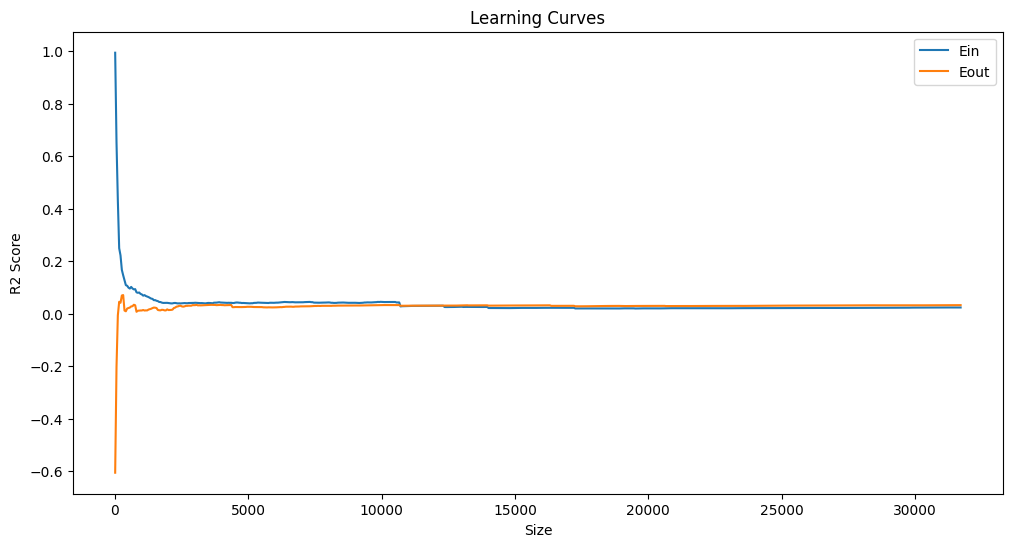

In [45]:
def learning_curves(model, X_train, y_train, X_test, y_test):
    train_scores = []
    test_scores = []
    for i in range(10, len(X_train), 50):
        model.fit(X_train[:i], y_train[:i])
        y_train_pred = model.predict(X_train[:i])
        y_test_pred = model.predict(X_test[:i])
        train_score = r2_score(y_train[:i], y_train_pred)
        test_score = r2_score(y_test[:i], y_test_pred)
        train_scores.append(train_score)
        test_scores.append(test_score)
    return train_scores, test_scores

train_scores, test_scores = learning_curves(modelo, x_train, y_train, x_test, y_test)

train_sizes = range(10, len(x_train)+1, 50)

plt.plot(train_sizes, train_scores, label='Ein')
plt.plot(train_sizes, test_scores, label='Eout')
plt.xlabel('Size')
plt.ylabel('R2 Score')
plt.title('Learning Curves')
plt.legend()
plt.show()


As can be seen, when there is little data, a greater error is obtained in the Eout and better results in the Ein, but when the sample size increases, we can see how they begin to behave in the same way.


It has a similar shape to the learning curve that was given to us as a reference, accompanied by the fact that it has a large error, it can be concluded that it is a very simple model that does not adapt well to the problem. In the reference photo, a type of error is used in which the higher the prediction, the more erroneous the prediction is, while when using *R^2* it is inverted, the higher the values, the better the model is.


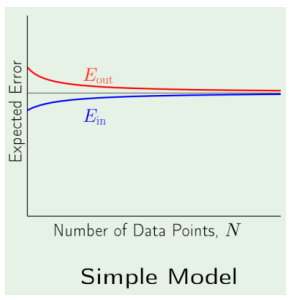


#### <font color='blue'>9) Now suppose that you must make this adjustment for a company that has provided you with the data, without distinction between training and testing. What would be the best model that you would propose, and what error would $E_{out}$ tell you it has? Justify all decisions. 0.5 points.


If I was in that situation, I would obtain the data they provide me and define $X$, $Y$ and $f$ to analyze the problem, know what data I have and how. 

After analyzing the problem and what is required, I would choose the linear models that I thought were most appropriate, in my case they were Linear Regression, Ridge and Lasso.

After this, I would divide the data into test and train sets, with a coherent proportion, which in my case was 20% for the test. At the same time, with the data analysis, I would know that in $X$ there are binary characteristics, so I would separate them from the continuous ones in the data to later give them their proper treatment. 

I would preprocess the continua, eliminating features that have a high correlation with others through the correlation matrix suitable for continuous data, I would adapt the outliers to not deal with outliers using the IQR method substituting values ​​and not eliminating so as not to lose information. I would normalize the data so that it is in scale so that I can later use PCA on it, thus reducing the dimensions of the data. It would check that there were no redundant values ​​in the binary data and would put them together again, obtaining the already transformed data.

I would define the metrics that I am going to use, in my case it was $R^2$ since the results are more interpretable as they are limited between 0 and 1, being able to see the percentage of prediction of the variability of the data.

You would deploy the models, getting an Ein by running them and using the metric. From these results I would choose the best one, which in my case is Lasso, although the results were very close to the other models.

With the best model chosen, I would obtain the Eout using the test data, which in my case was 0.03322... which suggests that the model explains approximately 3.32% of the variability of the data.

I would see the learning curves to know how my model adapts to the data and, in my case, concluding that it has not adapted, achieving poor predictions.

Finally I would communicate my results to the company, my best model being Lasso with an Eout of 0.03322... whose metric is $R^2$.
